<a href="https://colab.research.google.com/github/epythonlab2/AI_4_health/blob/main/module_2_model_deployment_interpretability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<header style="font-family: 'Inter', sans-serif; background: #ffffff; padding: 16px; border-radius: 8px; border: 1px solid #e1e4e8; display: flex; align-items: center; gap: 12px; box-shadow: 0 2px 8px rgba(0,0,0,0.05); margin-bottom: 10px;">
    <div style="width: 4px; height: 35px; background: linear-gradient(to bottom, #4e73df, #1cc88a); border-radius: 2px;"></div>
    <h1 style="color: #1a1a1a; margin: 0; font-size: 20px; font-weight: 700; border: none;"><strong>Module 2: Machine Learning and Statistics</strong></h1>
</header>

<div style="font-family: 'Inter', sans-serif; max-width: 900px; margin: 15px 0; padding: 20px; border-radius: 10px; background: #f1f4ff; border: 1px solid #dbe3ff; display: flex; align-items: center; justify-content: space-between; gap: 15px;">
    <div style="flex: 1;">
        <h2 style="margin: 0; color: #2e59d9; font-size: 18px; font-weight: 700; border: none;"><strong>Chapter 4: Model Deployment & Interpretability</strong></h2>
        <span style="display: inline-block; margin-top: 8px; background: #ffffff; padding: 4px 12px; border-radius: 6px; color: #4e73df; font-weight: 800; font-size: 11px; border: 1px solid #dbe3ff; text-transform: uppercase;">6 Hours</span>
    </div>

   <a href="https://linkedin.com/in/dejenet" target="_blank" style="background-color: #0077b5; color: white; padding: 10px 20px; border-radius: 8px; text-decoration: none; font-size: 14px; font-weight: 700; white-space: nowrap;">
        Connect on LinkedIn
    </a>
</div>

###**4.1 Saving and Loading Machine Learning Models**

Once a machine learning model is trained, it must be saved so it can be reused without retraining. This is essential for deployment, reproducibility, and version control.

In Python, the most common tools for this are **joblib** and **pickle**. For scikit-learn models, **joblib** is generally preferred because it handles large numerical arrays efficiently.

#### **4.1.1 Generate Heart Disease Dataset**
Let's pause the saving and loading ml model, generate the best clean datasets (No Data Cleaning Needed)

**Why this is the top choice**

- No missing values

- All numeric

- Clear medical meaning

- Works perfectly with **Flask** + **SHAP**

In [54]:
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np

# Generate synthetic dataset with 14 features
X, y = make_classification(
    n_samples=1000,
    n_features=14,
    n_informative=10,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    random_state=42
)

# Create DataFrame with heart-disease-style feature names
feature_names = [
    "age",
    "sex",
    "trestbps",
    "chol",
    "thalach",
    "fbs",
    "restecg",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "cp",
    "resting_hr"
]

df = pd.DataFrame(X, columns=feature_names)

# Convert some features to more realistic ranges

df["age"] = (df["age"] * 10 + 55).astype(int)
df["sex"] = np.where(df["sex"] > 0, 1, 0)
df["trestbps"] = (df["trestbps"] * 15 + 130).astype(int)
df["chol"] = (df["chol"] * 30 + 240).astype(int)
df["thalach"] = (df["thalach"] * 20 + 150).astype(int)
df["fbs"] = np.where(df["fbs"] > 0, 1, 0)
df["exang"] = np.where(df["exang"] > 0, 1, 0)
df["ca"] = np.clip((df["ca"] * 1.5 + 1).astype(int), 0, 3)

# Add target
df["target"] = y


In [55]:
df.head()

,age,sex,trestbps,chol,thalach,fbs,restecg,exang,oldpeak,slope,ca,thal,cp,resting_hr,target
0,57,1,135,203,141,0,0.374652,0,1.662872,0.682909,0,-0.096290,-0.706476,1.475155,0
1,33,0,107,323,143,0,-3.616860,0,-3.150791,0.153453,0,1.927038,-0.225723,1.335919,0
2,25,1,112,381,152,0,0.297226,1,-6.801806,1.573732,1,-0.348181,-3.033989,-2.326364,0
3,10,1,134,254,167,1,-1.654235,0,1.411960,-0.621943,0,-0.387911,0.313242,4.148565,1
4,-10,1,135,275,100,1,-1.126806,0,-2.691496,-0.259630,0,-0.205920,-0.589160,0.759591,1


| Column         | Type                                | Description / Clinical Relevance                                  |
| -------------- | ----------------------------------- | ----------------------------------------------------------------- |
| **age**        | Numeric                             | Patient age in years; older age → higher risk                     |
| **sex**        | Binary (0 = female, 1 = male)       | Sex-related risk differences                                      |
| **trestbps**   | Numeric                             | Resting blood pressure (mm Hg); high BP → higher risk             |
| **chol**       | Numeric                             | Serum cholesterol (mg/dL); high cholesterol → higher risk         |
| **thalach**    | Numeric                             | Max heart rate during exercise; lower values may indicate issues  |
| **fbs**        | Binary (0 ≤120 mg/dL, 1 >120 mg/dL) | High fasting blood sugar → higher risk                            |
| **restecg**    | Categorical                         | Resting ECG results; abnormal patterns → potential heart problems |
| **exang**      | Binary (0 = no, 1 = yes)            | Exercise-induced angina; yes → higher risk                        |
| **oldpeak**    | Numeric                             | ST depression during exercise; higher → potential ischemia        |
| **slope**      | Categorical                         | Slope of peak exercise ST segment; abnormal → cardiac stress      |
| **ca**         | Numeric (0–3)                       | Number of major vessels affected; higher → severe disease         |
| **thal**       | Categorical                         | Thalassemia test; abnormal → perfusion issues                     |
| **cp**         | Categorical                         | Chest pain type; indicates risk level                             |
| **resting_hr** | Numeric                             | Resting heart rate (bpm); higher → higher risk                    |
| **target**     | Binary                              | Heart disease: 0 = no, 1 = yes                                    |


**Use case**

- Classification API

- Feature importance visualization

- Zero preprocessing

- Great for demos and teaching

**1. Split and Train**
First, we split the data into a training set to "teach" the model and a testing set to "verify" its performance.

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Separate features & target
X = df.drop('target', axis=1)
y = df['target']

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

**2. Evaluate the Results**

For medical data, we don't just care about overall accuracy; we care about Precision and Recall (to ensure we aren't missing true positive cases).

In [57]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[94  3]
 [14 89]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92        97
           1       0.97      0.86      0.91       103

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.91       200
weighted avg       0.92      0.92      0.91       200



**3. Feature Importance**

One of the best parts of using a Random Forest is seeing which features the model relied on most to make a decision.

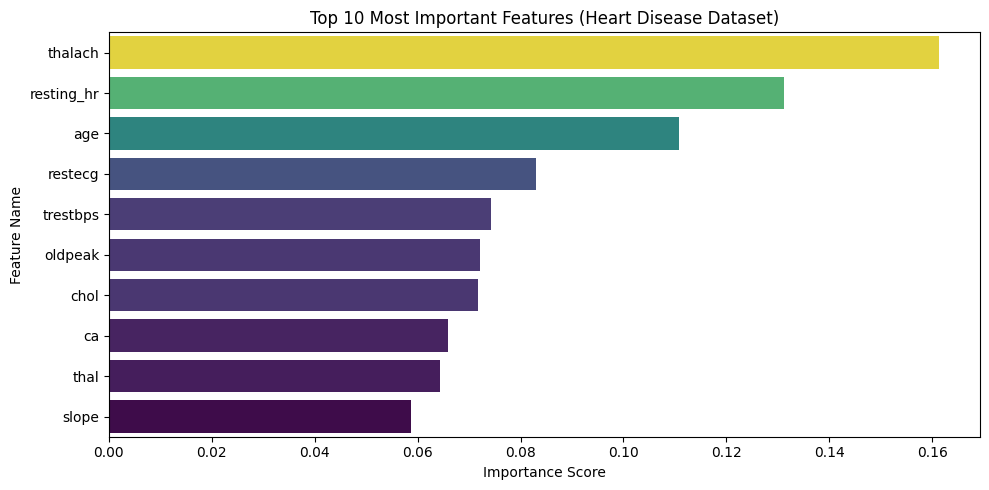

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Create a DataFrame for the importances
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 2. Sort and select the top 10 for better readability
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# 3. Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature',
            data=feature_importance_df,
            hue="Importance",
            legend=False,
            palette='viridis')

plt.title('Top 10 Most Important Features (Heart Disease Dataset)')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

**Key Concepts Applied**
- `train_test_split:` Prevents "overfitting" by ensuring the model is tested on data it has never seen before.
- $n\_estimators=100$: This tells the model to build 100 individual decision trees and average their results.
- Random State: Setting this to a fixed number (like 42) ensures your results are reproducible every time you run the code.

####**4.1.2 Saving & Loading using joblib and pickle**

Both **pickle** and **joblib** serve the same purpose: **serialization**. This means turning a Python object (your model) into a stream of bytes so it can be saved to a disk and "rehydrated" later.

While **pickle** is the standard Python tool, **joblib** is often preferred in the data science community, specifically for models like **Random Forests**.

**Saving a trained model**

In [59]:
import joblib

joblib.dump(model, "cancer.pkl")


['cancer.pkl']

**Loading the model**

In [60]:
model = joblib.load("cancer.pkl")

After loading, the model behaves exactly like the original trained model and can be used for inference on new patient data.

This separation between training and inference is a core principle in production ML systems.

###**4.2 SHAP Expalanability**

**What Is SHAP?**

**SHAP (SHapley Additive exPlanations)** is a method for explaining machine learning predictions that explains why a machine learning model made a specific prediction.



**It tells you:**

- Which features influenced the prediction

- How much each feature contributed

- Whether each feature pushed the prediction up or down

**It works for:** Classification, Regression, Tree models, Linear models, Even deep learning models



**The Core Idea (Simple Analogy)**

- Imagine a group project.
- The team gets a final score of 90.

**Now you ask:**

- “How much did each member contribute to that 90?”

- SHAP does the same thing for machine learning.

- The final score → model prediction

- The team members → input features

- The contribution → SHAP value

- It fairly distributes the prediction across the features.

**How SHAP Explains a Prediction**

- Every prediction starts from a baseline.

- Baseline = average prediction across all data.

- Then each feature adjusts that baseline.

**Example:**

Baseline risk = 50%

- High tumor radius = +25%

- High texture = +10%

- Low smoothness = +5%
- = Final prediction = 90%

SHAP shows this breakdown clearly.

**What a SHAP Value Means**

Each SHAP value tells you:

- Positive value → pushes prediction higher

- Negative value → pushes prediction lower

- Larger magnitude → stronger impact

So you see both **direction** and **strength**.

**Two Ways SHAP Explains Models**
1. Global Explanation

    - Which features matter most overall?

    - Used to understand the model’s general behavior.

2. Local Explanation

    - Why did the model predict this for this specific patient?

    - This is critical in healthcare.

**Why SHAP Is Important**

Many models are black boxes.They give predictions but no reasoning.

In healthcare, that’s not acceptable.

**SHAP helps:**

- Build trust

- Validate medical logic

- Detect bias

- Explain decisions to clinicians

It turns a black box into something understandable.

**Key takeaway:**

SHAP breaks a prediction into feature contributions so you can see exactly how the model reached its decision.

**Step 1 — Install SHAP**

In [61]:
#!pip install shap

**Step 2 — Create SHAP Explainer**



In [73]:
import shap
#shap.initjs()
explainer = shap.Explainer(model)
shap_values = explainer(X_train)

**Step 3 — Global Feature Importance ( Bar Plot Version ):- Cleaner for Presentations**


This shows which features matter most across the whole dataset.

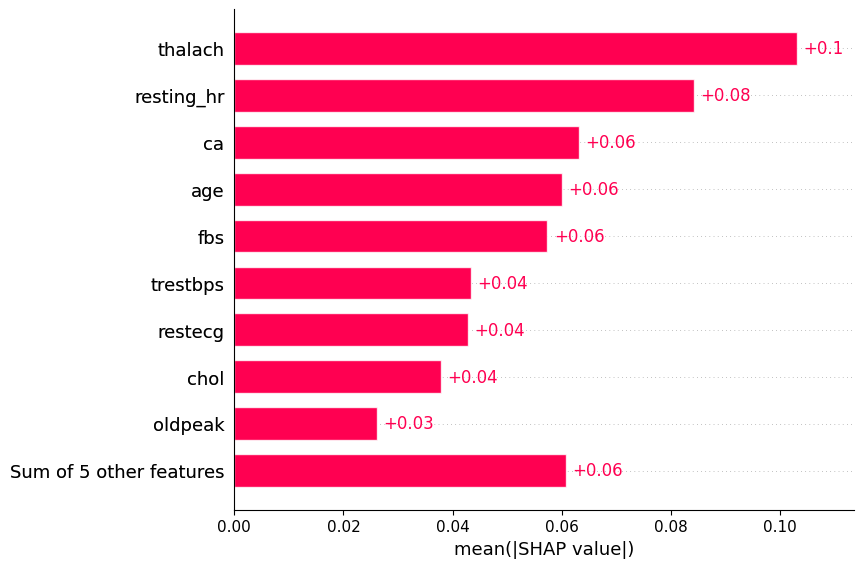

In [87]:
# bar plot
shap.plots.bar(shap_values[:,:,1])

`shap_values[:, :, 1]` means: take all samples, take all features, but only for
class 1.

If you used `[:, :, 0]`, you would be explaining the model output for class 0 instead.

This shows average absolute SHAP values — a clean feature importance ranking.

By default the bar plot only shows a maximum of ten bars, but this can be controlled with the `max_display` parameter:

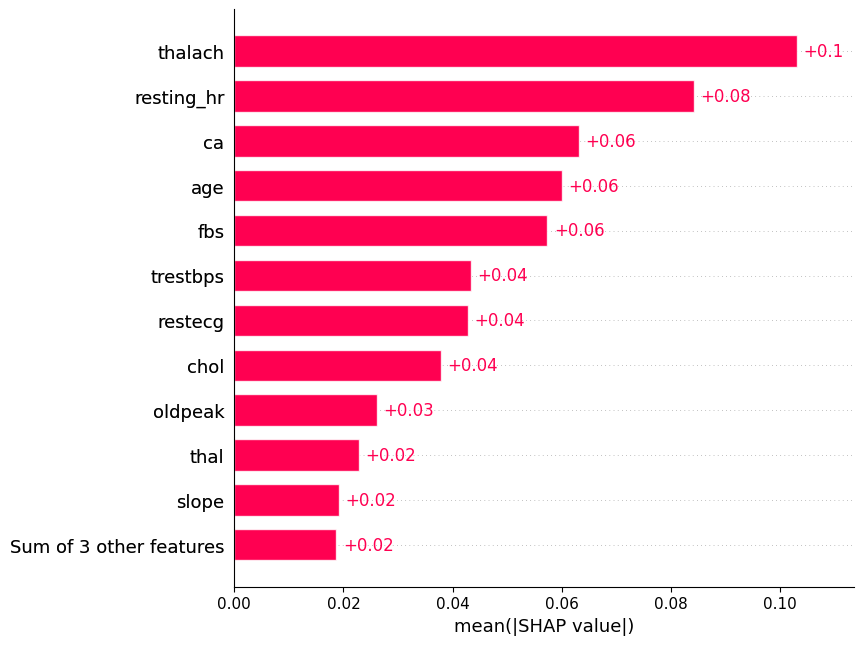

In [77]:
shap.plots.bar(shap_values[:,:,1], max_display=12)

1. **The X-Axis:** `mean(|SHAP value|)`
This represents the average impact a feature has on the model's output magnitude.
    - **The Math:** It takes the absolute SHAP value for every single prediction and averages them: $\text{average}(|\phi_i|)$.
    - **The Meaning:** A higher value means that feature is more "influential." If you changed the value of that feature, the model's prediction would likely swing significantly.

**2. Feature Importance**

RankingThe features are ranked from most important (top) to least important (bottom).

<table style="width:100%; border-collapse: collapse; font-family: 'Segoe UI', Arial, sans-serif; margin: 20px 0; border: 1px solid #ddd;">
  <thead>
    <tr style="background-color: #f8f9fa; border-bottom: 2px solid #e91e63;">
      <th style="padding: 12px; text-align: left; border: 1px solid #ddd;">Rank</th>
      <th style="padding: 12px; text-align: left; border: 1px solid #ddd;">Feature</th>
      <th style="padding: 12px; text-align: left; border: 1px solid #ddd;">mean(|SHAP value|)</th>
      <th style="padding: 12px; text-align: left; border: 1px solid #ddd;">Interpretation</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 10px; border: 1px solid #ddd;">1</td>
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold;">thalach</td>
      <td style="padding: 10px; border: 1px solid #ddd; color: #e91e63; font-weight: bold;">+0.10</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Strongest influence on prediction</td>
    </tr>
    <tr>
      <td style="padding: 10px; border: 1px solid #ddd;">2</td>
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold;">resting_hr</td>
      <td style="padding: 10px; border: 1px solid #ddd;">+0.08</td>
      <td style="padding: 10px; border: 1px solid #ddd;">High impact</td>
    </tr>
    <tr>
      <td style="padding: 10px; border: 1px solid #ddd;">3</td>
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold;">ca</td>
      <td style="padding: 10px; border: 1px solid #ddd;">+0.06</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Moderate–high importance</td>
    </tr>
    <tr>
      <td style="padding: 10px; border: 1px solid #ddd;">4</td>
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold;">age</td>
      <td style="padding: 10px; border: 1px solid #ddd;">+0.06</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Moderate importance</td>
    </tr>
    <tr>
      <td style="padding: 10px; border: 1px solid #ddd;">5</td>
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold;">fbs</td>
      <td style="padding: 10px; border: 1px solid #ddd;">+0.06</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Moderate importance</td>
    </tr>
    <tr style="background-color: #fffafa;">
      <td style="padding: 10px; border: 1px solid #ddd;">6</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Sum of 5 other features</td>
      <td style="padding: 10px; border: 1px solid #ddd;">+0.06</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Combined smaller effects</td>
    </tr>
    <tr>
      <td style="padding: 10px; border: 1px solid #ddd;">7</td>
      <td style="padding: 10px; border: 1px solid #ddd;">trestbps</td>
      <td style="padding: 10px; border: 1px solid #ddd;">+0.04</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Lower impact</td>
    </tr>
    <tr>
      <td style="padding: 10px; border: 1px solid #ddd;">8</td>
      <td style="padding: 10px; border: 1px solid #ddd;">restecg</td>
      <td style="padding: 10px; border: 1px solid #ddd;">+0.04</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Lower impact</td>
    </tr>
    <tr>
      <td style="padding: 10px; border: 1px solid #ddd;">9</td>
      <td style="padding: 10px; border: 1px solid #ddd;">chol</td>
      <td style="padding: 10px; border: 1px solid #ddd;">+0.04</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Lower impact</td>
    </tr>
    <tr>
      <td style="padding: 10px; border: 1px solid #ddd;">10</td>
      <td style="padding: 10px; border: 1px solid #ddd;">oldpeak</td>
      <td style="padding: 10px; border: 1px solid #ddd;">+0.03</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Least influence among shown</td>
    </tr>
  </tbody>
</table>

This is the **global interpretability view**.

**Step 5 — Explaining One Individual Prediction (Local Explanation)**

Let’s explain a single patient.

Passing a row of SHAP values to the bar plot function creates a local feature importance plot, where the bars are the SHAP values for each feature. Note that the feature values are show in gray to the left of the feature names.

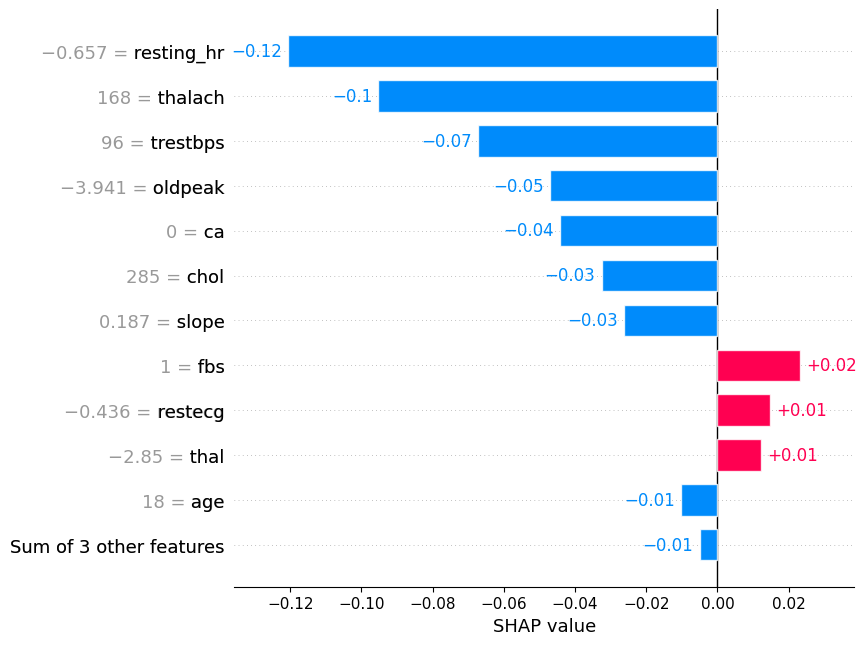

In [82]:
shap.plots.bar(shap_values[0, :, 1], max_display=12)


While the previous chart showed **global importance**, this is a **SHAP Waterfall (or Local Bar)** plot. It explains a single, specific prediction for one individual patient.

Instead of showing absolute averages, it shows how each feature value pushed the prediction higher **(red) or lower (blue)** feature value from the model's baseline.

| Feature         | SHAP Value | Direction of Impact | Notes                                     |
| --------------- | ---------- | ------------------- | ----------------------------------------- |
| `resting_hr`    | -0.12      | Negative            | Strongest feature reducing the prediction |
| `thalach`       | -0.10      | Negative            | Higher values reduce model output         |
| `trestbps`      | -0.07      | Negative            | Moderate negative contribution            |
| `oldpeak`       | -0.05      | Negative            | Slightly reduces output                   |
| `ca`            | -0.04      | Negative            | Slightly reduces output                   |
| `chol`          | -0.03      | Negative            | Minor negative contribution               |
| `slope`         | -0.03      | Negative            | Minor negative contribution               |
| `fbs`           | +0.02      | Positive            | Slightly increases model output           |
| `restecg`       | +0.01      | Positive            | Small positive contribution               |
| `thal`          | +0.01      | Positive            | Small positive contribution               |
| `age`           | -0.01      | Negative            | Negligible effect                         |
| Sum of 3 others | -0.01      | Negative            | Minor cumulative effect                   |


- `resting_hr`, thalach, and trestbps are the most important features, all pushing predictions downward.

- Features like `fbs`, `restecg`, and `thal` have a small positive effect.

- Most features in this model tend to decrease the predicted value rather than increase it.

**Bonus:**

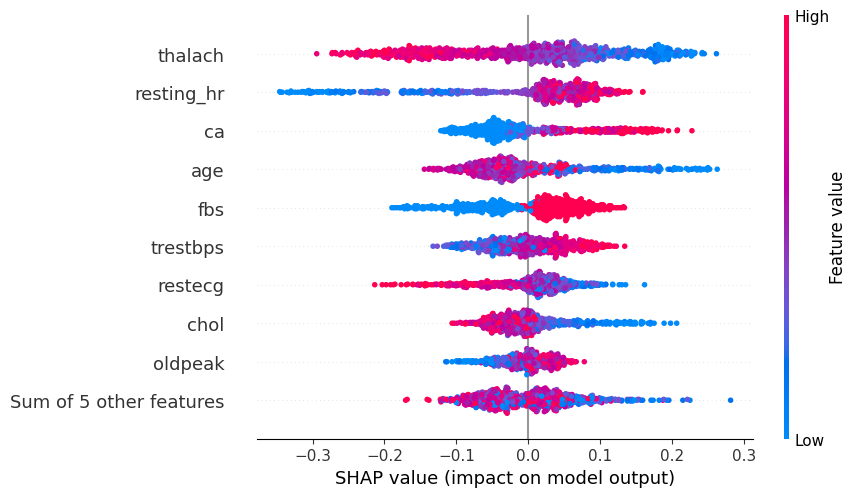

In [78]:
shap.plots.beeswarm(shap_values[:,:,1])

### **4.3 Deploy the model**

Tools:
- streamlit
- flask
- fastapi

In [ ]:
import streamlit as st
import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt

# 1. Page Config
st.set_page_config(page_title="Heart Disease AI", layout="wide")
st.title("🩺 Clinical Decision Support System")

# 2. Load the Saved Model and Explainer
@st.cache_resource
def load_assets(model_path):
    # Load your trained model (e.g., RandomForest, XGBoost, etc.)
    model = joblib.load(model_path)

    # We need a small sample of data to initialize the SHAP explainer
    # If you have a training set saved, load it here.
    # For now, we'll use a standard heart dataset sample for the 'background'
    X_background, _ = shap.datasets.heart()
    explainer = shap.Explainer(model, X_background)

    return model, explainer, X_background

# Replace 'heart_model.pkl' with your actual filename
try:
    model, explainer, X_bg = load_assets('heart_model.pkl')
except FileNotFoundError:
    st.error("Model file not found. Please ensure 'heart_model.pkl' is in the directory.")
    st.stop()

# 3. User Inputs (Matching your model features)
st.sidebar.header("Patient Data Entry")

def user_input_features():
    # Use the column names from your background data to ensure order matches
    inputs = {}
    inputs['age'] = st.sidebar.number_input("Age", value=50)
    inputs['sex'] = st.sidebar.selectbox("Sex (1=M, 0=F)", [1, 0])
    inputs['cp'] = st.sidebar.slider("Chest Pain Type (0-3)", 0, 3, 1)
    inputs['resting_hr'] = st.sidebar.number_input("Resting Heart Rate", value=75)
    inputs['exang'] = st.sidebar.selectbox("Exercise Angina (1=Yes, 0=No)", [1, 0])
    inputs['fbs'] = st.sidebar.selectbox("Fasting Blood Sugar > 120 (1=True, 0=False)", [1, 0])
    # Add other features like 'oldpeak', 'slope', 'ca', 'thal' as needed
    return pd.DataFrame([inputs])

input_df = user_input_features()

# 4. Display Prediction and SHAP Waterfall
col1, col2 = st.columns([1, 2])

with col1:
    st.subheader("Model Prediction")
    prediction = model.predict(input_df)[0]
    prob = model.predict_proba(input_df)[0][1]

    st.metric("Risk Score", f"{prob:.2f}")
    if prediction == 1:
        st.warning("Result: High Risk Indicator")
    else:
        st.success("Result: Low Risk Indicator")

with col2:
    st.subheader("Individual Risk Contribution")
    # Generate SHAP values for this specific input
    shap_values = explainer(input_df)

    fig, ax = plt.subplots()
    # Waterfall plots show how the base value moved to the final prediction
    shap.plots.waterfall(shap_values[0])
    st.pyplot(fig)

st.divider()
st.info("The Waterfall plot above explains exactly which patient metrics influenced this specific prediction.")